# Import


In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import re

import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sklearn.covariance import LedoitWolf

from matplotlib.gridspec import GridSpec
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
#plt.style.use('seaborn-v0_8-darkgrid')
from dashboard import PortfolioDashboardVisualizer
import cvxpy as cp


import QuantLib as ql
from functools import lru_cache

from finance import get_calendar, COUNTRY_DEFAULT_FREQ_MAP

from signal_model import (
    SignalConfig,
    compute_roll_bp_1m,
    orthogonalize_roll_vs_carry,
    apply_roll_to_signal,
    estimate_expected_returns_from_long,
)

import warnings

warnings.filterwarnings(
    "ignore",
    message="Values in x were outside bounds during a minimize step, clipping to bounds",
    category=RuntimeWarning,
)



## Helpers QuantLib

In [2]:
@lru_cache(maxsize=None)
def _build_bond(issue_date, maturity_date, coupon_dec, freq, country_iso):
    """
    Construit et cache un FixedRateBond QuantLib + liste des cashflows (dates/amounts).
    Face = 100, settlementDays=0 (carry calculé "trade-date", simple et stable).
    """
    cal = get_calendar(country_iso)

    daycount = ql.ActualActual(ql.ActualActual.ISMA)

    issue_ql = ql.Date(issue_date.day, issue_date.month, issue_date.year)
    mat_ql   = ql.Date(maturity_date.day, maturity_date.month, maturity_date.year)

    frequency = {1: ql.Annual, 2: ql.Semiannual, 4: ql.Quarterly}.get(int(freq), ql.Semiannual)

    schedule = ql.Schedule(
        issue_ql,
        mat_ql,
        ql.Period(frequency),
        cal,
        ql.Following,
        ql.Following,
        ql.DateGeneration.Backward,
        False,
    )

    face = 100.0
    bond = ql.FixedRateBond(0, face, schedule, [float(coupon_dec)], daycount)

    cfs = [(cf.date(), float(cf.amount())) for cf in bond.cashflows() if isinstance(cf, ql.Coupon)]
    cfs.sort(key=lambda x: x[0])

    return bond, cfs


def _compute_carry_for_isin(df_isin):
    """
    carry journalier (unité "return" / notional) = (Δaccrued + coupons payés) / 100
    sur l'intervalle (t_{k-1}, t_k].
    """
    df = df_isin.sort_values("time_stamp").copy()

    # Si metadata manquante, on retourne sur l'ancienne approximation
    if (df["issue_date"].isna().all() or df["maturity_date"].isna().all() or df["coupon_dec"].isna().all()):
        df["pnl_carry"] = (df["price"] / 100.0) * df["y_dec"] / 252.0
        return df

    issue_date    = df["issue_date"].iloc[0]
    maturity_date = df["maturity_date"].iloc[0]
    coupon_dec    = float(df["coupon_dec"].iloc[0])
    freq          = int(df["cpn_freq"].iloc[0])
    country_iso   = df["country_iso"].iloc[0]

    
    bond, cfs = _build_bond(issue_date, maturity_date, coupon_dec, freq, country_iso)

    cf_dates = [d for d, _ in cfs]
    cf_amts  = [a for _, a in cfs]

    carry = np.zeros(len(df), dtype=float)

    prev_ql = None
    accrued_prev = None
    k = 0  # pointeur cashflows

    for i, ts in enumerate(df["time_stamp"].tolist()):
        d = ql.Date(ts.day, ts.month, ts.year)

        accrued = float(bond.accruedAmount(d))  # en currency units sur face=100

        if prev_ql is None:
            carry[i] = 0.0
            # on ignore tout cashflow <= première date
            while k < len(cf_dates) and cf_dates[k] <= d:
                k += 1
        else:
            coupons = 0.0
            # ajoute les cashflows dans (prev_ql, d]
            while k < len(cf_dates) and cf_dates[k] <= d:
                coupons += cf_amts[k]
                k += 1

            carry_amount_px = (accrued - accrued_prev) + coupons  # "price points" sur base 100
            carry[i] = carry_amount_px / 100.0                   # -> return / notional

        prev_ql = d
        accrued_prev = accrued

    df["pnl_carry"] = carry
    return df


In [3]:
data = pd.read_csv("data/benchmark_mids_cs.csv")

data["time_stamp"] = pd.to_datetime(data["time_stamp"])

data = data.sort_values(["isin", "time_stamp"])

# Keep the last observation per day per ISIN
data = data.groupby(["isin", data["time_stamp"].dt.date], as_index=False).last()
data["time_stamp"] = pd.to_datetime(data["time_stamp"].dt.date)
print(data.shape)
data.head()

(26622, 10)


,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961


In [4]:

mid_bonds_close = pd.read_csv("data/mid_bonds_close_it_de_fr.csv")
mid_bonds_close.head()

,date,isin,yield
0,2023-11-09 00:00:00+00:00,IT0005445306,3.8200
1,2023-12-07 00:00:00+00:00,DE0001102564,2.0770
2,2023-12-22 00:00:00+00:00,FR0014004J31,2.9480
3,2023-11-24 00:00:00+00:00,DE0001135226,2.6785
4,2023-11-30 00:00:00+00:00,DE0001030559,0.2970


## Chargement des coupons par bond


In [5]:
meta = pd.read_csv("data/metadata_bonds.csv")

meta["issue_date"] = pd.to_datetime(meta["issue_date"], errors="coerce")
meta["maturity_date"] = pd.to_datetime(meta["maturity_date"], errors="coerce")

# coupon dans le fichier en %
meta["coupon_dec"] = pd.to_numeric(meta["coupon"], errors="coerce") / 100.0
meta["cpn_freq"] = pd.to_numeric(meta["cpn_freq"], errors="coerce")

meta = meta[["isin", "issue_date", "maturity_date", "coupon_dec", "cpn_freq"]].drop_duplicates("isin")

data = data.merge(meta, on="isin", how="left")

#on ajoute ça pour éviter les problèmes des NULL dans la fréquence de coupon dans la bdd donnée et bien garder les coupons à 0
data["cpn_freq"] = data["cpn_freq"].fillna(
    data["country_iso"].map(COUNTRY_DEFAULT_FREQ_MAP)
).fillna(2).astype(int)

data.head()



,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01,issue_date,maturity_date,coupon_dec,cpn_freq
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957,NaT,NaT,NaN,1
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962,NaT,NaT,NaN,1
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959,NaT,NaT,NaN,1
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966,NaT,NaT,NaN,1
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961,NaT,NaT,NaN,1


# Data Pipeline

In [6]:

# --- Typing & sorting ---
data["time_stamp"] = pd.to_datetime(data["time_stamp"])
data["mat_cat"] = data["mat_cat"].astype(str)

data = (
    data
    .sort_values(["isin", "time_stamp"])
    .reset_index(drop=True)
)

# --- Yield level & changes ---
data["y_dec"] = data["yield"] / 100.0

data["dy"] = (
    data
    .groupby("isin")["y_dec"]
    .diff()
)
data["dy_bp"] = data["dy"] * 1e4

# Carry propre via coupons donnés
bad_isins = [
    "FR001400FYQ4", "IT0005607269", "FR001400PM68", "FR001400HI98",
    "IT0005566408", "IT0005518128", "IT0005521981", "IT0005584849",
    "IT0005560948", "IT0005500068", "IT0005611055", "DE0001135226",
    "DE000BU22056", "IT0005637399", "DE000BU2F009", "IT0005631590",
    "FR001400OHF4", "DE000BU22064", "IT0005657330", "IT0005582421"
]
data = data[~data["isin"].isin(bad_isins)]
try:
    data = data.groupby("isin", group_keys=False).apply(
        _compute_carry_for_isin, include_groups=False
    )
except TypeError:
    data = data.groupby("isin", group_keys=False).apply(_compute_carry_for_isin)


# VERSION 1 : PnL (unité return / notional)
data["pnl_yield"] = -data["dv01"] * data["dy_bp"]
data["pnl_total_unit"] = data["pnl_yield"] + data["pnl_carry"]


# VERSION 2 : RETURN NORMALISÉ DV01 (en bp)
eps = 1e-12
data["carry_bp_equiv"] = np.where(
    np.abs(data["dv01"]) > eps,
    data["pnl_carry"] / data["dv01"],
    0.0,
)
data["ret_total_per_dv01"] = -data["dy_bp"] + data["carry_bp_equiv"]

data.head()

,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01,issue_date,...,coupon_dec,cpn_freq,y_dec,dy,dy_bp,pnl_carry,pnl_yield,pnl_total_unit,carry_bp_equiv,ret_total_per_dv01
0,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957,NaT,...,NaN,1,0.005400,NaN,NaN,0.000022,NaN,NaN,0.023346,NaN
1,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962,NaT,...,NaN,1,0.004965,-0.000435,-4.35,0.000021,0.004183,0.004203,0.021456,4.371456
2,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959,NaT,...,NaN,1,0.005165,0.000200,2.00,0.000021,-0.001917,-0.001896,0.022345,-1.977655
3,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966,NaT,...,NaN,1,0.004450,-0.000715,-7.15,0.000019,0.006904,0.006923,0.019240,7.169240
4,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961,NaT,...,NaN,1,0.004835,0.000385,3.85,0.000020,-0.003702,-0.003681,0.020921,-3.829079


In [7]:

"""
data_roll = data.copy()

# 1) compute roll-down (bp, horizon 1M)
data_roll = compute_roll_bp_1m(
    data_roll,
    date_col="time_stamp",
    country_col="country_iso",
    maturity_col="remaining_maturity",
    curve_node_col="mat_cat",
    yield_col="yield",
    yield_in_percent=True,      # ton yield est en %
    horizon_months=1,
    out_col="roll_bp_1m",
    clip_bp=25.0
)

# 2) orthogonalize roll vs carry
data_roll = orthogonalize_roll_vs_carry(
    data_roll,
    date_col="time_stamp",
    carry_col="carry_bp_equiv",
    roll_col="roll_bp_1m",
    out_col="roll_ortho_bp"
)

# 3) sanity check quant
print(data_roll["roll_bp_1m"].describe())
print(data_roll[["carry_bp_equiv", "roll_bp_1m", "roll_ortho_bp"]].corr())
"""


'\ndata_roll = data.copy()\n\n# 1) compute roll-down (bp, horizon 1M)\ndata_roll = compute_roll_bp_1m(\n    data_roll,\n    date_col="time_stamp",\n    country_col="country_iso",\n    maturity_col="remaining_maturity",\n    curve_node_col="mat_cat",\n    yield_col="yield",\n    yield_in_percent=True,      # ton yield est en %\n    horizon_months=1,\n    out_col="roll_bp_1m",\n    clip_bp=25.0\n)\n\n# 2) orthogonalize roll vs carry\ndata_roll = orthogonalize_roll_vs_carry(\n    data_roll,\n    date_col="time_stamp",\n    carry_col="carry_bp_equiv",\n    roll_col="roll_bp_1m",\n    out_col="roll_ortho_bp"\n)\n\n# 3) sanity check quant\nprint(data_roll["roll_bp_1m"].describe())\nprint(data_roll[["carry_bp_equiv", "roll_bp_1m", "roll_ortho_bp"]].corr())\n'

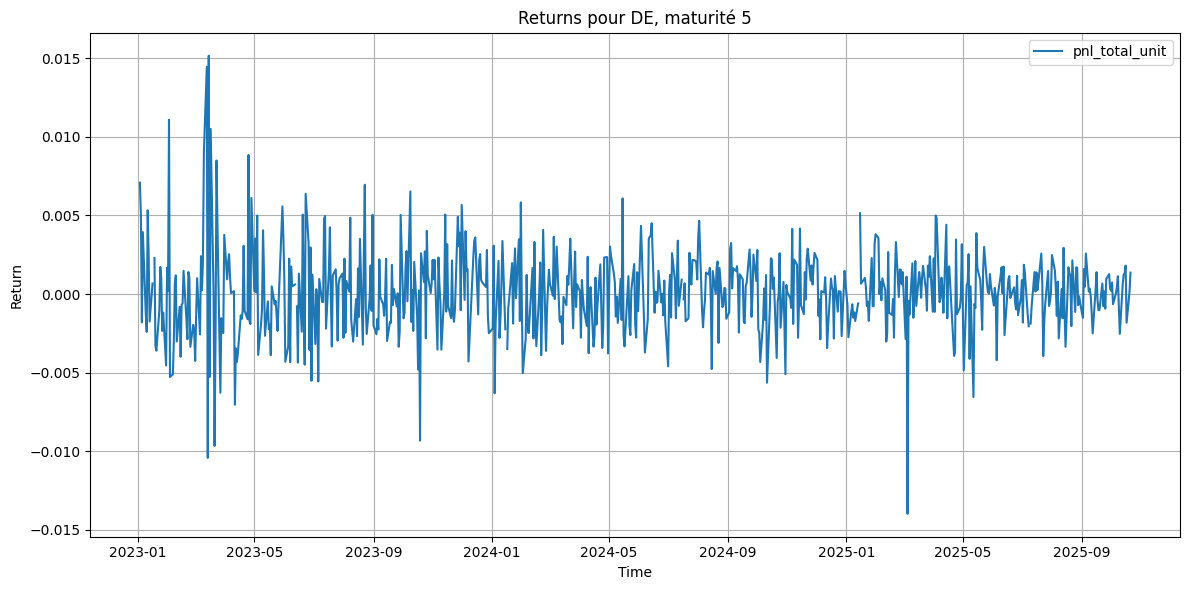

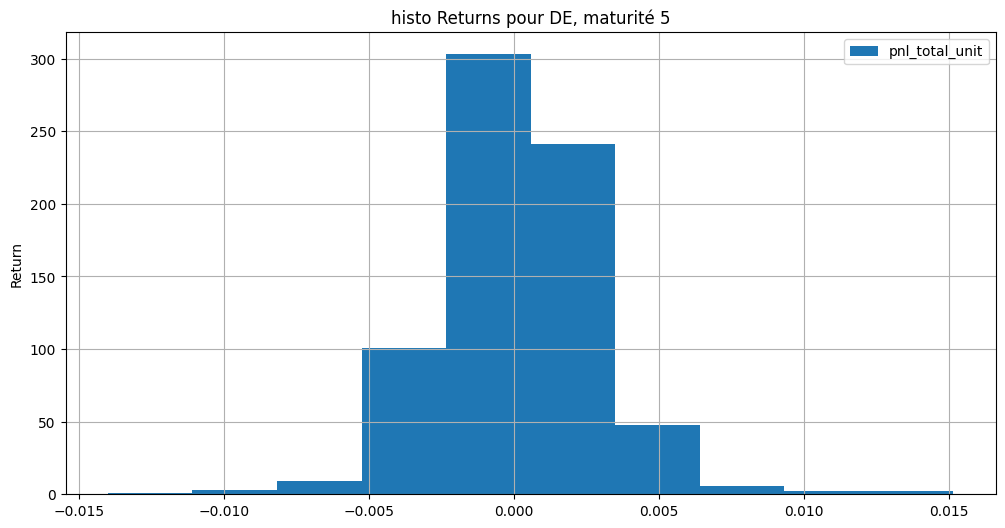

In [8]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Variables à modifier facilement
# -----------------------------
country = "DE"                # Pays à filtrer
maturity = "5"                # Maturité à filtrer (valeur de mat_cat)
return_col1 = "ret_total_per_dv01"   # Colonne de return DV01
return_col2 = "pnl_total_unit" # Colonne de coupon quotidien
return_col3 = "pnl_total_unit"    # Colonne de return total

start_date = "2023-01-01"    # Date de début du plot
end_date = "2025-12-31"      # Date de fin du plot

# -----------------------------
# Filtrage du DataFrame
# -----------------------------
df_plot = data.loc[
    (data["country_iso"] == country) &
    (data["mat_cat"] == maturity) &
    (data["time_stamp"] >= pd.to_datetime(start_date)) &
    (data["time_stamp"] <= pd.to_datetime(end_date))
]

# -----------------------------
# Plot avec matplotlib
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(df_plot["time_stamp"], df_plot[return_col2], label=return_col2, linestyle="-")
plt.title(f"Returns pour {country}, maturité {maturity}")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.hist(df_plot[return_col2], label=return_col2)
plt.title(f"histo Returns pour {country}, maturité {maturity}")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

In [9]:

data

,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01,issue_date,...,coupon_dec,cpn_freq,y_dec,dy,dy_bp,pnl_carry,pnl_yield,pnl_total_unit,carry_bp_equiv,ret_total_per_dv01
0,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957,NaT,...,NaN,1,0.005400,NaN,NaN,0.000022,NaN,NaN,0.023346,NaN
1,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962,NaT,...,NaN,1,0.004965,-0.000435,-4.35,0.000021,0.004183,0.004203,0.021456,4.371456
2,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959,NaT,...,NaN,1,0.005165,0.000200,2.00,0.000021,-0.001917,-0.001896,0.022345,-1.977655
3,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966,NaT,...,NaN,1,0.004450,-0.000715,-7.15,0.000019,0.006904,0.006923,0.019240,7.169240
4,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961,NaT,...,NaN,1,0.004835,0.000385,3.85,0.000020,-0.003702,-0.003681,0.020921,-3.829079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26417,32815022,2025-10-15,100.6650,3.8270,IT,15,ref,14.959617,0.001120,2025-02-18,...,0.0385,2,0.038270,-0.000254,-2.54,0.000106,0.002845,0.002950,0.094446,2.634446
26418,32832218,2025-10-16,100.9550,3.8010,IT,15,ref,14.956879,0.001124,2025-02-18,...,0.0385,2,0.038010,-0.000260,-2.60,0.000106,0.002922,0.003028,0.094119,2.694119
26419,32849394,2025-10-17,100.5820,3.8343,IT,15,ref,14.954141,0.001119,2025-02-18,...,0.0385,2,0.038343,0.000333,3.33,0.000106,-0.003725,-0.003619,0.094553,-3.235447
26420,32866577,2025-10-20,100.8850,3.8072,IT,15,ref,14.945927,0.001123,2025-02-18,...,0.0385,2,0.038072,-0.000271,-2.71,0.000317,0.003042,0.003359,0.282675,2.992675


In [10]:
#On met data sous le bon format. Ce qu'on veut c'est :
# Date | Finacial product (ex FR_5 pour France bond mat 5) | Return
val1 = "ret_total_per_dv01"
val2 = "pnl_total_unit"

data_completed = data[["time_stamp", "country_iso", "mat_cat", val1, val2, "dv01","maturity_date"]].copy()
data_completed["product"] = data_completed["country_iso"].astype(str) + "_" + data_completed["mat_cat"].astype(str)
data_completed = data_completed.drop(columns=["country_iso", "mat_cat"])
data_completed["time_stamp"] = pd.to_datetime(data_completed["time_stamp"])
dv01_ref = data_completed["dv01"].median()
data_completed.head()

,time_stamp,ret_total_per_dv01,pnl_total_unit,dv01,maturity_date,product
0,2015-01-01,NaN,NaN,0.000957,NaT,DE_10
1,2015-01-02,4.371456,0.004203,0.000962,NaT,DE_10
2,2015-01-05,-1.977655,-0.001896,0.000959,NaT,DE_10
3,2015-01-06,7.169240,0.006923,0.000966,NaT,DE_10
4,2015-01-07,-3.829079,-0.003681,0.000961,NaT,DE_10


## Chargement des bid-offer par bond

In [11]:
bo = pd.read_csv("data/bid_offer_CS.csv")  # adapte le nom si besoin
# Harmonise les types
bo["mat_cat"] = bo["mat_cat"].astype(str)

# On définit le product bond simple : "FR_5", "DE_10", etc.
bo["product"] = bo["country_iso"].astype(str) + "_" + bo["mat_cat"].astype(str)

# On agrège par product (médiane par ex. s'il y a plusieurs ISIN dans le bucket)
bond_bidoffer_yield = (
    bo.groupby("product")["q25_spread_yield"]
    .median()
    .rename("bidoffer_yield_bond")
)
bond_bidoffer_yield_bp = bond_bidoffer_yield 
bond_bidoffer_yield.head()


product
AT_10    0.006
AT_15    0.011
AT_2     0.023
AT_20    0.008
AT_3     0.017
Name: bidoffer_yield_bond, dtype: float64

# Ajout spread et curve 

In [12]:
def add_spread_curve(
    data,
    value_col="pnl_total_unit",
    bond_bidoffer_yield=None
):
    df = data.copy()

    product_type = {p: "bond" for p in df["product"].unique()}

    products = df["product"].unique()
    countries = sorted({p.split("_")[0] for p in products})

    def sort_mats(mats):
        try:
            return sorted(mats, key=lambda x: float(x))
        except ValueError:
            return sorted(mats)

    maturities = sort_mats({p.split("_")[1] for p in products})

    wide = (
        df
        .pivot(index="time_stamp", columns="product", values=value_col)
        .sort_index()
    )

    # --- Bid / offer par produit ---
    bidoffer_product = {}
    if bond_bidoffer_yield is not None:
        for p in wide.columns:
            if p in bond_bidoffer_yield.index:
                bidoffer_product[p] = bond_bidoffer_yield.loc[p]

    # ============================
    # MATURITY DATE PAR BOND
    # ============================
    # On prend la maturity_date médiane (ou first) par bond depuis data_completed
    maturity_by_bond = {}
    if "maturity_date" in df.columns:
        maturity_by_bond = (
            df.groupby("product")["maturity_date"]
            .first()          # toutes les lignes d'un bond ont la même date
            .to_dict()
        )

    def min_maturity(*bond_names):
        """Retourne la plus petite maturity_date parmi les bonds listés."""
        dates = [maturity_by_bond[b] for b in bond_names if b in maturity_by_bond]
        return min(dates) if dates else pd.NaT

    # dict product -> maturity_date (initialisé avec les bonds simples)
    maturity_product = dict(maturity_by_bond)

    # ============================
    # 1) SPREADS ENTRE PAYS
    # ============================
    for mat in maturities:
        prods_mat = [f"{c}_{mat}" for c in countries if f"{c}_{mat}" in wide.columns]

        for i in range(len(prods_mat)):
            for j in range(i + 1, len(prods_mat)):
                p1, p2 = prods_mat[i], prods_mat[j]
                c1, c2 = p1.split("_")[0], p2.split("_")[0]

                spread_name = f"{c1}_{c2}_{mat}"
                if spread_name not in wide.columns:
                    wide[spread_name] = wide[p1] - wide[p2]
                    product_type[spread_name] = "spread_country"
                    maturity_product[spread_name] = min_maturity(p1, p2)   # ← NEW

                    if bond_bidoffer_yield is not None:
                        bo1 = bidoffer_product.get(p1, np.nan)
                        bo2 = bidoffer_product.get(p2, np.nan)
                        if np.isfinite(bo1) and np.isfinite(bo2):
                            bidoffer_product[spread_name] = (
                                0.5 * (bo1 + bo2) * bid_offer_multiplier["spread"]
                            )

    # ============================
    # 2) SPREADS DE COURBE
    # ============================
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c + "_")])

        for i in range(len(mats_c)):
            for j in range(i + 1, len(mats_c)):
                m1, m2 = mats_c[i], mats_c[j]
                p1, p2 = f"{c}_{m1}", f"{c}_{m2}"

                if p1 in wide.columns and p2 in wide.columns:
                    spread_name = f"{c}_{m1}_{m2}"
                    if spread_name not in wide.columns:
                        wide[spread_name] = wide[p1] - wide[p2]
                        product_type[spread_name] = "spread_curve"
                        maturity_product[spread_name] = min_maturity(p1, p2)  # ← NEW

                        if bond_bidoffer_yield is not None:
                            bo1 = bidoffer_product.get(p1, np.nan)
                            bo2 = bidoffer_product.get(p2, np.nan)
                            if np.isfinite(bo1) and np.isfinite(bo2):
                                bidoffer_product[spread_name] = (
                                    0.5 * (bo1 + bo2) * bid_offer_multiplier["curve"]
                                )

    # ============================
    # 3) BUTTERFLIES
    # ============================
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c + "_")])

        for i in range(len(mats_c) - 2):
            m1, m2, m3 = mats_c[i], mats_c[i + 1], mats_c[i + 2]
            p1, p2, p3 = f"{c}_{m1}", f"{c}_{m2}", f"{c}_{m3}"

            if all(p in wide.columns for p in (p1, p2, p3)):
                fly_name = f"{c}_fly_{m1}_{m2}_{m3}"
                if fly_name not in wide.columns:
                    wide[fly_name] = wide[p1] - 2 * wide[p2] + wide[p3]
                    product_type[fly_name] = "butterfly_curve"
                    maturity_product[fly_name] = min_maturity(p1, p2, p3)  # ← NEW

                    if bond_bidoffer_yield is not None:
                        bo1 = bidoffer_product.get(p1, np.nan)
                        bo2 = bidoffer_product.get(p2, np.nan)
                        bo3 = bidoffer_product.get(p3, np.nan)
                        if np.isfinite(bo1) and np.isfinite(bo2) and np.isfinite(bo3):
                            bidoffer_product[fly_name] = (
                                0.5 * (bo1 + bo2 + bo3) * bid_offer_multiplier["fly"]
                            )

    # ============================
    # 4) BOX / SLOPE DIFF
    # ============================
    for idx_low in range(len(maturities) - 1):
        for idx_high in range(idx_low + 1, len(maturities)):
            m_low, m_high = maturities[idx_low], maturities[idx_high]

            for i in range(len(countries)):
                for j in range(i + 1, len(countries)):
                    c1, c2 = countries[i], countries[j]
                    p1_low, p1_high = f"{c1}_{m_low}", f"{c1}_{m_high}"
                    p2_low, p2_high = f"{c2}_{m_low}", f"{c2}_{m_high}"

                    if all(p in wide.columns for p in (p1_low, p1_high, p2_low, p2_high)):
                        slope_name = f"{c1}_{c2}_slope_{m_low}_{m_high}"
                        if slope_name not in wide.columns:
                            wide[slope_name] = (
                                (wide[p1_high] - wide[p1_low]) -
                                (wide[p2_high] - wide[p2_low])
                            )
                            product_type[slope_name] = "slope_diff_country"
                            maturity_product[slope_name] = min_maturity(   # ← NEW
                                p1_low, p1_high, p2_low, p2_high
                            )

                            if bond_bidoffer_yield is not None:
                                bo1_low  = bidoffer_product.get(p1_low,  np.nan)
                                bo1_high = bidoffer_product.get(p1_high, np.nan)
                                bo2_low  = bidoffer_product.get(p2_low,  np.nan)
                                bo2_high = bidoffer_product.get(p2_high, np.nan)

                                if all(np.isfinite(x) for x in [bo1_low, bo1_high, bo2_low, bo2_high]):
                                    bidoffer_product[slope_name] = (
                                        0.5 * (bo1_low + bo1_high + bo2_low + bo2_high)
                                        * bid_offer_multiplier["box"]
                                    )

    # ============================
    # Retour format long
    # ============================
    long = wide.reset_index().melt(
        id_vars="time_stamp",
        var_name="product",
        value_name=value_col
    )

    long["type"] = long["product"].map(product_type).fillna("unknown")

    # ← NEW : maturity_date sur tous les produits
    if maturity_by_bond:
        long["maturity_date"] = long["product"].map(maturity_product)

    if bond_bidoffer_yield is not None:
        bo_series = pd.Series(bidoffer_product)
        long["bid_offer_yield"] = long["product"].map(bo_series)

    return long

In [13]:
bid_offer_multiplier = {
    "fly": 0.25,
    "box": 0.375,
    "spread": 0.5,
    "curve": 0.4,
}

long = add_spread_curve(data_completed, value_col="pnl_total_unit", bond_bidoffer_yield=bond_bidoffer_yield_bp)
long2 = add_spread_curve(data_completed, value_col="ret_total_per_dv01", bond_bidoffer_yield=bond_bidoffer_yield_bp)
long_dv01 = add_spread_curve(data_completed, value_col="dv01", bond_bidoffer_yield=None)

dv01_by_product = long_dv01.groupby("product")["dv01"].median()

long["ret_total_per_dv01"] = long2["ret_total_per_dv01"]

In [14]:
long_bond = long[long["type"] == "bond"][["time_stamp", "product", "bid_offer_yield"]]
long_bond = data_completed.merge(long_bond, on=["time_stamp", "product"])
long_bond

,time_stamp,ret_total_per_dv01,pnl_total_unit,dv01,maturity_date,product,bid_offer_yield
0,2015-01-01,NaN,NaN,0.000957,NaT,DE_10,0.003
1,2015-01-02,4.371456,0.004203,0.000962,NaT,DE_10,0.003
2,2015-01-05,-1.977655,-0.001896,0.000959,NaT,DE_10,0.003
3,2015-01-06,7.169240,0.006923,0.000966,NaT,DE_10,0.003
4,2015-01-07,-3.829079,-0.003681,0.000961,NaT,DE_10,0.003
...,...,...,...,...,...,...,...
23201,2025-10-15,2.634446,0.002950,0.001120,2040-10-01,IT_15,0.004
23202,2025-10-16,2.694119,0.003028,0.001124,2040-10-01,IT_15,0.004
23203,2025-10-17,-3.235447,-0.003619,0.001119,2040-10-01,IT_15,0.004
23204,2025-10-20,2.992675,0.003359,0.001123,2040-10-01,IT_15,0.004


# Class Portfolio à date t 

In [15]:
import re
import warnings
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf


# =============================================================================
#  CLASSE Portfolio
# =============================================================================

class Portfolio:
    def __init__(
        self,
        data,
        date,
        benchmark="ew",
        long_only=True,
        lamb=0.1,
        rebalancement='ME',
        span=6,
        initial_weights=None,
        initial_positions=None,
        delta=0.1,
        tc_gamma=0.1
    ):
        # --- données et date ---
        self.data = data
        self.date = pd.to_datetime(date)
        self.benchmark = benchmark

        # --- paramètres optimisation ---
        self.long_only = long_only
        self.lamb = float(lamb)
        self.rebalancement = rebalancement
        self.span = span
        self.delta = delta
        self.tc_gamma = float(tc_gamma)
        self.initial_weights = initial_weights

        # 🔴 FIX 1 : self.countries dérivé des produits du dataset
        products = data["product"].unique()
        self.countries = sorted({
            p.split("_")[0] for p in products
            if len(p.split("_")) >= 2
            and len(p.split("_")[0]) == 2
            and p.split("_")[0].isalpha()
        })

        # --- attributs internes ---
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.weights = None
        self.benchmark_weights = None
        self.rolls_done = {}        # 🔴 NEW : TC des rolls décidés par update_positions

        # --- positions ---
        self.positions = initial_positions

    # =========================================================================
    # get_returns_until
    # =========================================================================
    def get_returns_until(self):
        """Filter returns up to self.date and resample according to rebalancement."""
        R = self.data[self.data["time_stamp"] < self.date].copy()

        if hasattr(self, "rebalancement") and self.rebalancement in ["D", "W", "ME"]:
            df_list = []
            for prod, df_prod in R.groupby("product"):
                df_prod = df_prod.set_index("time_stamp").sort_index()
                if self.rebalancement != "D":
                    df_resampled = df_prod["ret_total_per_dv01"].resample(self.rebalancement).sum()
                else:
                    df_resampled = df_prod["ret_total_per_dv01"]
                df_resampled = df_resampled.reset_index()
                df_resampled["product"] = prod
                df_list.append(df_resampled)
            R = pd.concat(df_list, axis=0)

        self.returns = R.sort_values(["product", "time_stamp"])

    # =========================================================================
    # estimate_returns
    # =========================================================================
    def estimate_returns(self):
        """EWMA of returns per product, shifted by 1 day to avoid look-ahead."""
        span = self.span
        df = self.returns[["time_stamp", "product", "ret_total_per_dv01"]].copy()
        df = df.sort_values(["product", "time_stamp"])
        df["ret_total_per_dv01"] = df.groupby("product")["ret_total_per_dv01"].shift(1)

        ewma = (
            df.groupby("product")["ret_total_per_dv01"]
            .apply(lambda x: x.ewm(span=span, adjust=False).mean().iloc[-1])
            .reset_index(name="ewma_ret_dv01")
        )
        self.mean_returns = ewma

    # =========================================================================
    # estimate_cov_matrix_Ledoit  (fallback)
    # =========================================================================
    def estimate_cov_matrix_Ledoit(self):
        panel = self.returns.pivot(
            index="time_stamp", columns="product", values="ret_total_per_dv01"
        ).sort_index()
        panel_clean = panel.dropna(axis=0, how="any")

        if len(panel_clean) < 2:
            warnings.warn(
                f"Only {len(panel_clean)} overlapping dates at {self.date}. "
                "Using diagonal estimate."
            )
            var = panel.var(skipna=True).fillna(0.0).values
            cov_matrix = np.diag(var)
        else:
            lw = LedoitWolf().fit(panel_clean.values)
            cov_matrix = lw.covariance_

        self.cov_matrix = pd.DataFrame(cov_matrix, columns=panel.columns, index=panel.columns)

    # =========================================================================
    # estimate_cov_matrix_factor  (recommandé pour portefeuilles avec composés)
    # =========================================================================
    def estimate_cov_matrix_factor(self, halflife=63, shrinkage=0.2):
        """
        Factor risk model : Σ = B @ F @ B.T + D
        Recommandé dès que le portefeuille contient spreads / flies / slopes.
        """
        panel = self.returns.pivot(
            index="time_stamp", columns="product", values="ret_total_per_dv01"
        ).sort_index()
        products = list(panel.columns)
        n_products = len(products)

        base_pattern = re.compile(r'^([A-Z]{2})_(\d+)$')
        base_bonds = [p for p in products if base_pattern.match(p)]

        if len(base_bonds) < 2:
            warnings.warn("Cannot identify base bonds — falling back to Ledoit-Wolf")
            return self.estimate_cov_matrix_Ledoit()

        factor_idx = {b: i for i, b in enumerate(base_bonds)}
        n_base = len(base_bonds)
        n_factors = n_base + 1
        market_col = n_base

        B = np.zeros((n_products, n_factors))
        country_weights = {"DE": 0.30, "FR": 0.25, "IT": 0.25, "SP": 0.20}

        for i, prod in enumerate(products):
            parts = prod.split("_")

            if base_pattern.match(prod):
                B[i, factor_idx[prod]] = 1.0
                B[i, market_col] = country_weights.get(parts[0], 0.25)

            elif "fly" in parts:
                fly_pos = parts.index("fly")
                country = parts[0]
                mats = parts[fly_pos + 1:]
                if len(mats) == 3:
                    keys = [f"{country}_{m}" for m in mats]
                    if all(k in factor_idx for k in keys):
                        B[i, factor_idx[keys[0]]] =  1.0
                        B[i, factor_idx[keys[1]]] = -2.0
                        B[i, factor_idx[keys[2]]] =  1.0

            elif "Ny" in parts:
                ny_pos = parts.index("Ny")
                country = parts[0]
                mats = parts[ny_pos + 1:]
                if len(mats) == 3:
                    keys = [f"{country}_{m}" for m in mats]
                    if all(k in factor_idx for k in keys):
                        B[i, factor_idx[keys[0]]] =  1.0
                        B[i, factor_idx[keys[1]]] = -2.0
                        B[i, factor_idx[keys[2]]] =  1.0

            elif "slope" in parts:
                slope_pos = parts.index("slope")
                c1, c2 = parts[0], parts[1]
                mats = parts[slope_pos + 1:]
                if len(mats) == 2:
                    m_low, m_high = mats
                    keys = [f"{c1}_{m_low}", f"{c1}_{m_high}", f"{c2}_{m_low}", f"{c2}_{m_high}"]
                    if all(k in factor_idx for k in keys):
                        B[i, factor_idx[keys[0]]] = -1.0
                        B[i, factor_idx[keys[1]]] =  1.0
                        B[i, factor_idx[keys[2]]] =  1.0
                        B[i, factor_idx[keys[3]]] = -1.0

            elif len(parts) == 3 and all(len(p) == 2 and p.isalpha() for p in parts[:2]):
                # spread pays : FR_DE_5
                c1, c2, mat = parts
                p1, p2 = f"{c1}_{mat}", f"{c2}_{mat}"
                if p1 in factor_idx and p2 in factor_idx:
                    B[i, factor_idx[p1]] =  1.0
                    B[i, factor_idx[p2]] = -1.0
                    B[i, market_col] = country_weights.get(c1, 0.25) - country_weights.get(c2, 0.25)

            elif len(parts) == 3 and len(parts[0]) == 2 and parts[0].isalpha():
                # spread courbe : FR_2_10
                country, m1, m2 = parts
                p1, p2 = f"{country}_{m1}", f"{country}_{m2}"
                if p1 in factor_idx and p2 in factor_idx:
                    B[i, factor_idx[p1]] =  1.0
                    B[i, factor_idx[p2]] = -1.0

        factor_returns_raw   = panel[base_bonds].copy()
        factor_returns_clean = factor_returns_raw.dropna(how="any")

        if len(factor_returns_clean) < n_base + 1:
            warnings.warn("Not enough data for factor model — falling back to Ledoit-Wolf")
            return self.estimate_cov_matrix_Ledoit()

        # Facteur marché
        market_return = pd.Series(0.0, index=factor_returns_clean.index)
        total_w = 0.0
        for bond in base_bonds:
            w = country_weights.get(bond.split("_")[0], 0.25)
            market_return += w * factor_returns_clean[bond]
            total_w += w
        market_return /= total_w

        factor_matrix = factor_returns_clean.copy()
        factor_matrix["_MARKET_"] = market_return
        factor_vals = factor_matrix.values
        T = factor_vals.shape[0]

        # EWMA factor covariance
        ewma_w = np.exp(-np.log(2) / halflife * np.arange(T)[::-1])
        ewma_w /= ewma_w.sum()
        mu_f = (ewma_w[:, None] * factor_vals).sum(axis=0)
        centered = factor_vals - mu_f
        F = (centered * ewma_w[:, None]).T @ centered
        F = (1 - shrinkage) * F + shrinkage * np.diag(np.diag(F))
        F = 0.5 * (F + F.T) + 1e-10 * np.eye(n_factors)

        Sigma_factor = B @ F @ B.T

        # Variance idiosyncratique EWMA
        factor_panel_full = panel[base_bonds].fillna(0).copy()
        factor_panel_full["_MARKET_"] = 0.0
        for bond in base_bonds:
            w = country_weights.get(bond.split("_")[0], 0.25)
            factor_panel_full["_MARKET_"] += w * panel[base_bonds].fillna(0)[bond]
        factor_panel_full["_MARKET_"] /= total_w

        predicted  = factor_panel_full.values @ B.T
        actual     = panel[products].fillna(0).values
        residuals  = actual - predicted

        T_full = residuals.shape[0]
        ewma_w_full = np.exp(-np.log(2) / halflife * np.arange(T_full)[::-1])
        ewma_w_full /= ewma_w_full.sum()
        d = (ewma_w_full[:, None] * residuals**2).sum(axis=0)
        D = np.diag(np.maximum(d, 1e-10))

        Sigma = 0.5 * (Sigma_factor + D + (Sigma_factor + D).T) + 1e-8 * np.eye(n_products)
        self.cov_matrix = pd.DataFrame(Sigma, columns=products, index=products)

    # =========================================================================
    # markowitz_robust
    # =========================================================================
    def markowitz_robust(self):
        mean_returns = (
            self.mean_returns
            .set_index("product")["ewma_ret_dv01"]
            .reindex(self.cov_matrix.index)
            .fillna(0.0)
            .values
        )
        cov_matrix = self.cov_matrix.values
        n = len(mean_returns)

        if self.initial_weights is None:
            w_prev = np.ones(n) / n
        elif isinstance(self.initial_weights, pd.Series):
            w_prev = self.initial_weights.reindex(self.cov_matrix.index).fillna(0.0).values
        elif isinstance(self.initial_weights, pd.DataFrame):
            w_prev = self.initial_weights.iloc[:, 0].reindex(self.cov_matrix.index).fillna(0.0).values
        else:
            w_prev = np.asarray(self.initial_weights, dtype=float)
            if w_prev.shape[0] != n:
                raise ValueError(f"initial_weights length {w_prev.shape[0]} != covariance dim {n}")

        if "bid_offer_yield" in self.data.columns:
            c_vec = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
                .reindex(self.cov_matrix.index)
                .fillna(0.0)
                .values
            )
        else:
            c_vec = np.zeros(n)

        lambda_risk = self.lamb
        gamma_tc    = self.tc_gamma
        eps_tc      = 1e-8

        w_ref      = np.ones(n) / n
        scale_risk = max(w_ref @ cov_matrix @ w_ref, 1e-12)
        scale_mean = max(abs(w_ref @ mean_returns),   1e-12)
        if gamma_tc > 0.0 and np.any(c_vec != 0):
            diff_ref  = w_ref - w_prev
            scale_tc  = max(np.sum(c_vec * np.sqrt(diff_ref**2 + eps_tc)), 1e-12)
        else:
            scale_tc  = 1.0

        def objective(w):
            risk_term = lambda_risk * (w @ cov_matrix @ w) / scale_risk
            mean_term = -(w @ mean_returns) / scale_mean
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff    = w - w_prev
                tc_term = gamma_tc * np.sum(c_vec * np.sqrt(diff**2 + eps_tc)) / scale_tc
            else:
                tc_term = 0.0
            return risk_term + mean_term + tc_term

        def grad_objective(w):
            grad_risk = 2.0 * lambda_risk * (cov_matrix @ w) / scale_risk
            grad_mean = -mean_returns / scale_mean
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff     = w - w_prev
                grad_tc  = gamma_tc * c_vec * (diff / np.sqrt(diff**2 + eps_tc)) / scale_tc
            else:
                grad_tc  = np.zeros_like(w)
            return grad_risk + grad_mean + grad_tc

        constraints = [{'type': 'eq',
                         'fun': lambda w: np.sum(w) - 1.0,
                         'jac': lambda w: np.ones_like(w)}]

        bounds = []
        for wp in w_prev:
            if self.long_only:
                bounds.append((max(0.0,  wp - 0.2), min(1.0, wp + 0.2)))
            else:
                bounds.append((max(-1.0, wp - 0.2), min(1.0, wp + 0.2)))

        w0 = np.clip(w_prev, [b[0] for b in bounds], [b[1] for b in bounds])
        w0 = np.ones(n) / n if w0.sum() == 0 else w0 / w0.sum()

        res = minimize(
            objective, w0, jac=grad_objective,
            constraints=constraints, bounds=bounds,
            method='SLSQP', options={'ftol': 1e-9, 'disp': False, 'maxiter': 1000}
        )

        if not res.success:
            print(f"Optimisation échouée à {self.date} — reprise des poids précédents")
            w_opt = w_prev.copy()
        else:
            w_opt = res.x

        w_opt[np.abs(w_opt) < 1e-4] = 0.0
        w_sum = w_opt.sum()
        if w_sum != 0:
            w_opt /= w_sum

        self.weights = pd.DataFrame(w_opt, index=self.cov_matrix.index, columns=[self.date])
        return self.weights

    # =========================================================================
    # update_positions — corrigé + retourne rolls_done
    # =========================================================================
    def update_postions(self):
        """
        Roll-down logic.

        🔴 FIX 2 : mu_old = mu_new pour les composés (pas d'aging_ratio)
        🔴 FIX 3 : _safe_get remplace row.get() incompatible avec pd.Series
        🟡 FIX 5 : maturity_date lue directement depuis self.data
        🔴 NEW   : rolls_done  dict[product -> tc_bp] retourné et stocké
        """
        MIN_MATURITY_FLOOR = 0.5

        # ── helpers ──────────────────────────────────────────────────────────

        def _safe_get(row, key):
            """🔴 FIX 3 : accès unifié Series / dict."""
            if isinstance(row, dict):
                return row.get(key, None)
            return row[key] if key in row.index else None

        def _remaining_maturity(row, date):
            mat = _safe_get(row, "maturity_date")
            if mat is None or (isinstance(mat, float) and np.isnan(mat)):
                return np.nan
            return (pd.to_datetime(mat) - date).days / 365.25

        def _product_type(product):
            """🔴 FIX 1 : utilise self.countries."""
            parts = product.split("_")
            if len(parts) == 2:
                return "bond"
            if len(parts) == 5 and parts[1] == "fly":
                return "butterfly"
            if len(parts) >= 4 and "slope" in parts:
                return "slope_diff"
            if len(parts) == 3:
                p0, p1 = parts[0], parts[1]
                if p0 in self.countries and p1 in self.countries:
                    return "spread_country"
                if p0 in self.countries:
                    return "spread_curve"
            return "unknown"

        def _legs(product):
            parts = product.split("_")
            ptype = _product_type(product)
            if ptype == "bond":
                return [(product, 1.0)]
            if ptype == "spread_country":
                c1, c2, mat = parts
                return [(f"{c1}_{mat}", 1.0), (f"{c2}_{mat}", -1.0)]
            if ptype == "spread_curve":
                c, m1, m2 = parts
                return [(f"{c}_{m1}", 1.0), (f"{c}_{m2}", -1.0)]
            if ptype == "butterfly":
                c, _, m1, m2, m3 = parts
                return [(f"{c}_{m1}", 1.0), (f"{c}_{m2}", -2.0), (f"{c}_{m3}", 1.0)]
            if ptype == "slope_diff":
                c1, c2, _, m_low, m_high = parts
                return [
                    (f"{c1}_{m_high}",  1.0),
                    (f"{c1}_{m_low}",  -1.0),
                    (f"{c2}_{m_high}", -1.0),
                    (f"{c2}_{m_low}",   1.0),
                ]
            return [(product, 1.0)]

        def _get_latest_row(product):
            df_p = self.data[
                (self.data["product"] == product) &
                (self.data["time_stamp"] <= self.date)
            ]
            return None if df_p.empty else df_p.iloc[-1]

        def _tc_roll(product):
            """TC de roll en bp (unité de ret_total_per_dv01)."""
            total_tc = 0.0
            for leg_prod, coef in _legs(product):
                row = _get_latest_row(leg_prod)
                if row is None:
                    continue
                bo = _safe_get(row, "bid_offer_yield")
                if bo is None or (isinstance(bo, float) and np.isnan(bo)):
                    bo = 0.0
                total_tc += abs(coef) * float(bo) * 1e4
            return total_tc

        def _remaining_maturity_from_data(product):
            """🟡 FIX 5 : lit maturity_date directement (déjà min des legs)."""
            row = _get_latest_row(product)
            if row is None:
                return np.nan
            return _remaining_maturity(row, self.date)

        def _get_mu(product):
            mr = self.mean_returns.set_index("product")
            return float(mr.loc[product, "ewma_ret_dv01"]) if product in mr.index else 0.0

        def _get_sigma2(product):
            if self.cov_matrix is not None and product in self.cov_matrix.index:
                return float(self.cov_matrix.loc[product, product])
            return 0.0

        # ── initialisation (premier appel) ────────────────────────────────────
        if self.positions is None:
            cols = ["ret_total_per_dv01", "pnl_total_unit", "dv01",
                    "maturity_date", "product", "bid_offer_yield"]
            available_cols = [c for c in cols if c in self.data.columns]
            snap = (
                self.data[self.data["time_stamp"] == self.date][available_cols]
                .copy()
                .set_index("product")
                .reindex(self.weights.index)
            )
            self.positions = snap
            if "maturity_date" in self.positions.columns:
                self.positions.loc[self.positions["maturity_date"].isna(), "maturity_date"] = self.date
            self.rolls_done = {}
            return {}

        # ── décision de roll ──────────────────────────────────────────────────
        rolls_done = {}

        for product, w in self.weights[self.date].items():
            if w == 0:
                continue

            ptype = _product_type(product)

            if product not in self.positions.index:
                bm_row = _get_latest_row(product)
                if bm_row is not None:
                    self.positions.loc[product] = bm_row
                continue

            # Maturité résiduelle (🟡 FIX 5 : lecture directe)
            T_old = _remaining_maturity_from_data(product)

            # Force roll si trop proche de la maturité
            if not (T_old is None or np.isnan(T_old)) and T_old < MIN_MATURITY_FLOOR:
                bm_row = _get_latest_row(product)
                if bm_row is not None:
                    self.positions.loc[product] = bm_row
                    tc_bp = _tc_roll(product)
                    rolls_done[product] = tc_bp  # 🔴 NEW : force roll aussi compté
                continue

            mu_new  = _get_mu(product)
            sigma2  = _get_sigma2(product)
            bm_row  = _get_latest_row(product)

            # 🔴 FIX 2 : aging_ratio uniquement pour les bonds simples
            if ptype == "bond":
                T_new = np.nan
                if bm_row is not None:
                    T_new = _remaining_maturity(bm_row, self.date)
                if (
                    not np.isnan(T_new if T_new is not None else float("nan"))
                    and T_new > 0
                    and T_old is not None
                    and not np.isnan(T_old)
                ):
                    aging_ratio = T_old / T_new
                else:
                    aging_ratio = 1.0
                mu_old = mu_new * aging_ratio
            else:
                # Composés : pas de vieillissement, seul le TC fremine le roll
                mu_old = mu_new

            tc_roll   = self.tc_gamma * _tc_roll(product)
            U_keep    = mu_old - self.lamb * sigma2
            U_replace = mu_new - self.lamb * sigma2 - tc_roll

            if U_replace > U_keep:
                if bm_row is not None:
                    self.positions.loc[product] = bm_row
                    rolls_done[product] = _tc_roll(product)  # 🔴 NEW

        # Remplissage des maturity_date manquantes
        if "maturity_date" in self.positions.columns:
            self.positions.loc[self.positions["maturity_date"].isna(), "maturity_date"] = self.date

        self.rolls_done = rolls_done
        return rolls_done

    # =========================================================================
    # benchmark_w
    # =========================================================================
    def benchmark_w(self):
        n = len(self.mean_returns)
        if self.benchmark == "ew":
            self.benchmark_weights = pd.DataFrame(
                np.ones(n) / n,
                index=self.mean_returns["product"],
                columns=[self.date]
            )
        else:
            raise NotImplementedError("Only 'ew' benchmark implemented.")

    # =========================================================================
    # process  — 🟡 FIX 4 : factor cov par défaut
    # =========================================================================
    def process(self):
        self.get_returns_until()
        self.estimate_returns()
        self.estimate_cov_matrix_factor()   # Ledoit reste dispo comme fallback
        self.markowitz_robust()
        self.update_postions()
        self.benchmark_w()
        return self.weights

In [16]:
date = "2021-06-01"


pf = Portfolio(long, date, benchmark="ew", long_only=True,lamb=0.5, tc_gamma=0.1 )
#print(pf.returns)
w = pf.process()
#print(pf.mean_returns)
print(w)

                 2021-06-01
DE_10              0.000000
DE_10_15           0.000000
DE_10_30           0.000000
DE_15              0.000000
DE_15_30           0.000000
...                     ...
IT_5_15            0.210101
IT_5_30            0.210101
IT_fly_10_15_30    0.000000
IT_fly_2_5_10      0.000000
IT_fly_5_10_15     0.000000

[99 rows x 1 columns]


# Creation du time series portfolio

In [39]:

# =============================================================================
#  CLASSE TimeSeriesPortfolio
# =============================================================================

class TimeSeriesPortfolio:
    def __init__(
        self,
        data,
        start_date,
        end_date,
        rebalance_freq='ME',
        long_only=False,
        lamb=1,
        benchmark="ew",
        capital_init=100_000,
        span=6,
        initial_weights=None,
        delta=0.1,
        tc_gamma=1,
        use_qp=False
    ):
        self.data = data.copy()
        self.data["time_stamp"] = pd.to_datetime(self.data["time_stamp"])
        self.start_date      = pd.to_datetime(start_date)
        self.end_date        = pd.to_datetime(end_date)
        self.rebalance_freq  = rebalance_freq
        self.long_only       = long_only
        self.lamb            = float(lamb)
        self.benchmark       = benchmark
        self.capital_init    = capital_init
        self.span            = span
        self.tc_gamma        = float(tc_gamma)
        self.delta           = delta
        self.initial_weights = initial_weights

        self.asset_universe = sorted(self.data["product"].unique())
        self.countries = sorted({
            p.split("_")[0] for p in self.asset_universe
            if len(p.split("_")[0]) == 2 and p.split("_")[0].isalpha()
        })

        self.rebalance_dates    = None
        self.all_dates          = None
        self.weights_history    = pd.DataFrame()
        self.exposures_history  = pd.DataFrame()
        self.portfolio_returns  = pd.Series(dtype=float)
        self.benchmark_returns  = pd.Series(dtype=float)
        self.metrics            = {}

        # bid-offer par produit
        if "bid_offer_yield" in self.data.columns:
            self.bidoffer_by_product = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
                .rename("bid_offer_yield")
            )
        else:
            self.bidoffer_by_product = pd.Series(0.0, index=self.asset_universe)

        # 🔴 FIX : dv01 par produit (était manquant)
        if "dv01" in self.data.columns:
            self.dv01_by_product = (
                self.data.groupby("product")["dv01"]
                .median()
                .rename("dv01")
            )
        else:
            self.dv01_by_product = pd.Series(0.0, index=self.asset_universe)

        start_window = self.start_date - pd.Timedelta(days=5_000)
        self.R = self.data[
            (self.data["time_stamp"] >= start_window) &
            (self.data["time_stamp"] <= self.end_date)
        ]

    # =========================================================================
    # freq_to_pd_freq
    # =========================================================================
    def freq_to_pd_freq(self):
        f = self.rebalance_freq.upper()
        if f == 'ME':
            return f
        if f.endswith(('D', 'B', 'W')):
            return f
        return 'ME'

    # =========================================================================
    # generate_rebalance_dates
    # =========================================================================
    def generate_rebalance_dates(self):
        all_dates = pd.DatetimeIndex(self.R["time_stamp"].unique())
        mask      = (all_dates >= self.start_date) & (all_dates <= self.end_date)
        all_dates = all_dates[mask].sort_values()
        self.all_dates = all_dates

        if len(all_dates) == 0:
            raise ValueError("No market dates in the selected window.")

        targets = pd.date_range(
            start=self.start_date, end=self.end_date,
            freq=self.freq_to_pd_freq()
        )
        reb = []
        for tgt in targets:
            tgt = pd.Timestamp(tgt)
            pos = all_dates.searchsorted(tgt)
            if pos < len(all_dates):
                d = all_dates[pos]
                if (len(reb) == 0) or (d != reb[-1]):
                    reb.append(d)

        if all_dates[-1] not in reb:
            reb.append(all_dates[-1])

        self.rebalance_dates = pd.DatetimeIndex(reb)

    # =========================================================================
    # generate_portfolios
    # =========================================================================
    def generate_portfolios(self):
        if self.rebalance_dates is None or self.all_dates is None:
            self.generate_rebalance_dates()

        weights_list    = []
        exposures_list  = []

        pf_rel_returns  = []
        bm_rel_returns  = []
        returns_dates   = []

        pf_pnl_daily    = []
        bm_pnl_daily    = []

        # TC tracking — séparés Markowitz vs roll-down
        tc_dates              = []
        tc_values             = []
        tc_markowitz_values   = []
        tc_rolldown_values    = []

        capital           = self.capital_init
        current_value     = capital
        current_value_bm  = capital
        w                 = self.initial_weights
        positions         = None

        prev_exposure_full = pd.Series(0.0, index=self.asset_universe)

        # 🟡 FIX : bid-offer en bp (décimal * 1e4), était * 100
        bo_full = self.bidoffer_by_product.reindex(self.asset_universe).fillna(0.0)
        bo_bp   = bo_full.values * 1e4

        for i, t in enumerate(self.rebalance_dates[:-1]):
            t_next = self.rebalance_dates[i + 1]

            pf = Portfolio(
                data=self.data,
                date=t,
                benchmark=self.benchmark,
                long_only=self.long_only,
                lamb=self.lamb,
                span=self.span,
                initial_weights=w,
                initial_positions=positions,
                delta=self.delta,
                tc_gamma=self.tc_gamma
            )

            w_df          = pf.process()
            new_positions = pf.positions
            rolls_done    = pf.rolls_done   # 🔴 NEW : dict product -> tc_bp

            w      = w_df.iloc[:, 0]
            w_full = w.reindex(self.asset_universe).fillna(0.0)
            w_bm   = pf.benchmark_weights.reindex(self.asset_universe).iloc[:, 0].fillna(0.0)

            # Normalisation sur DV01 cible
            target_dv01 = self.capital_init * dv01_ref

            denom_pf = np.sum(np.abs(w_full.values))
            exposure_full = w_full * (target_dv01 / denom_pf) if denom_pf > 0 else w_full.copy()

            denom_bm = np.sum(np.abs(w_bm.values))
            exposure_bm_full = w_bm * (target_dv01 / denom_bm) if denom_bm > 0 else w_bm.copy()

            # ── TC Markowitz (delta de poids) ────────────────────────────────
            delta_exposure_full = exposure_full - prev_exposure_full
            # Masque des produits qui ont rollé — leur TC est déjà dans tc_rolldown
            rolled_products = set(rolls_done.keys())
            roll_mask = np.array([
                1.0 if p not in rolled_products else 0.0
                for p in self.asset_universe
            ])
            tc_markowitz = float(np.sum(np.abs(delta_exposure_full.values) * bo_bp * roll_mask))/1e4 

            # ── TC Roll-down (rolls décidés par update_positions) ────────────
            # rolls_done[product] = tc_bp (en bp de ret_total_per_dv01)
            # PnL roll = |expo_product| * tc_bp / 1e4
            tc_rolldown = 0.0
            for product, tc_bp_prod in rolls_done.items():
                expo_prod = float(exposure_full.get(product, 0.0))
                tc_rolldown += abs(expo_prod) * float(tc_bp_prod) / 1e4
                tc_rolldown = tc_rolldown/2

            tc_total = tc_markowitz+ tc_rolldown

            prev_exposure_full = exposure_full.copy()

            # ── PnL sur la période (t, t_next] ───────────────────────────────
            period_mask  = (self.R["time_stamp"] > t) & (self.R["time_stamp"] <= t_next)
            R_slice_long = self.R.loc[period_mask].copy()

            R_slice = R_slice_long.pivot(
                index="time_stamp", columns="product", values="ret_total_per_dv01"
            )
            common_cols = [p for p in self.asset_universe if p in R_slice.columns]
            R_slice     = R_slice[common_cols].fillna(0.0)

            exp_pf = exposure_full.reindex(common_cols).values
            exp_bm = exposure_bm_full.reindex(common_cols).values

            pf_pnl_day = R_slice.values @ exp_pf
            bm_pnl_day = R_slice.values @ exp_bm

            # Imputation du TC au premier jour de la période
            if len(pf_pnl_day) > 0:
                pf_pnl_day[0] -= tc_total
                tc_dates.append(R_slice.index[0])
            else:
                tc_dates.append(t)
                pf_pnl_day = np.array([-tc_total])
                bm_pnl_day = np.array([0.0])
                R_slice = pd.DataFrame(
                    index=[t],
                    data=np.zeros((1, len(common_cols))),
                    columns=common_cols
                )

            tc_values.append(tc_total)
            tc_markowitz_values.append(tc_markowitz)
            tc_rolldown_values.append(tc_rolldown)

            pf_pnl_daily.extend(pf_pnl_day)
            bm_pnl_daily.extend(bm_pnl_day)

            pf_rel_returns.extend((pf_pnl_day / current_value).tolist())
            bm_rel_returns.extend((bm_pnl_day / current_value_bm).tolist())
            returns_dates.extend(R_slice.index.tolist())

            current_value     += pf_pnl_day.sum()
            current_value_bm  += bm_pnl_day.sum()

            weights_list.append(w_full.values)
            exposures_list.append(exposure_full.values)

            positions = new_positions

        # ── Historiques ──────────────────────────────────────────────────────
        asset_names = self.asset_universe
        self.weights_history = pd.DataFrame(
            weights_list, index=self.rebalance_dates[:-1], columns=asset_names
        )
        self.exposures_history = pd.DataFrame(
            exposures_list, index=self.rebalance_dates[:-1], columns=asset_names
        )

        if len(returns_dates) > 0:
            idx = pd.DatetimeIndex(returns_dates)
            self.portfolio_returns = pd.Series(pf_rel_returns, index=idx)
            self.benchmark_returns = pd.Series(bm_rel_returns, index=idx)

        # ── Métriques ─────────────────────────────────────────────────────────
        pf_cum_return = (1 + self.portfolio_returns.fillna(0)).cumprod()
        bm_cum_return = (1 + self.benchmark_returns.fillna(0)).cumprod()

        idx_ret  = pd.DatetimeIndex(returns_dates)
        pf_value = pd.Series(capital + np.array(pf_pnl_daily).cumsum(), index=idx_ret)
        bm_value = pd.Series(capital + np.array(bm_pnl_daily).cumsum(), index=idx_ret)
        pf_pnl   = pd.Series(pf_pnl_daily, index=idx_ret)
        bm_pnl   = pd.Series(bm_pnl_daily, index=idx_ret)

        trading_days = 252
        pf_mean   = self.portfolio_returns.mean()
        pf_std    = self.portfolio_returns.std()
        pf_sharpe = (pf_mean / pf_std * np.sqrt(trading_days)) if pf_std != 0 else np.nan

        roll_max = pf_value.cummax() if len(pf_value) > 0 else pd.Series(dtype=float)
        dd       = (pf_value - roll_max) / roll_max if len(pf_value) > 0 else pd.Series(dtype=float)

        tc_idx = pd.DatetimeIndex(tc_dates)

        self.metrics = {
            "initial_capital":             capital,
            "portfolio_value":             pf_value,
            "benchmark_value":             bm_value,
            "portfolio_pnl":               pf_pnl,
            "benchmark_pnl":               bm_pnl,
            "pf_cumulative_return":        pf_cum_return,
            "bm_cumulative_return":        bm_cum_return,
            "mean_return":                 pf_mean,
            "volatility":                  pf_std,
            "sharpe":                      pf_sharpe,
            "gross_exposure":              np.abs(self.exposures_history).sum(axis=1),
            "net_exposure":                self.exposures_history.sum(axis=1),
            "drawdown":                    dd,
            "max_drawdown":                dd.min() if len(dd) > 0 else np.nan,
            # TC détaillés ────────────────────────────────────────────────────
            "transaction_costs":           pd.Series(tc_values,           index=tc_idx),
            "transaction_costs_markowitz": pd.Series(tc_markowitz_values, index=tc_idx),
            "transaction_costs_rolldown":  pd.Series(tc_rolldown_values,  index=tc_idx),
        }

        print("Tout a marché !!")

    # =========================================================================
    # _decompose_product_legs — inchangé
    # =========================================================================
    def _decompose_product_legs(self, product):
        parts = product.split("_")

        if len(parts) == 2:
            c, m = parts
            return [(c, m, 1.0)]

        if len(parts) == 3:
            p0, p1, p2 = parts
            if p0 in getattr(self, "countries", []) and p1 in getattr(self, "countries", []):
                return [(p0, p2, 1.0), (p1, p2, -1.0)]
            if p0 in getattr(self, "countries", []):
                return [(p0, p1, 1.0), (p0, p2, -1.0)]

        if len(parts) == 5 and parts[1] == "fly":
            c, _, m1, m2, m3 = parts
            return [(c, m1, 1.0), (c, m2, -2.0), (c, m3, 1.0)]

        if len(parts) == 5 and parts[2] == "slope":
            c1, c2, _, m_low, m_high = parts
            return [
                (c1, m_high,  1.0),
                (c1, m_low,  -1.0),
                (c2, m_high, -1.0),
                (c2, m_low,   1.0),
            ]

        return []

    # =========================================================================
    # exposition_by_country — inchangé
    # =========================================================================
    def exposition_by_country(self):
        df = self.exposures_history.copy()
        legs_by_product = {p: self._decompose_product_legs(p) for p in df.columns}
        countries = sorted({c for legs in legs_by_product.values() for c, m, coef in legs})

        if not countries:
            return pd.DataFrame(index=df.index)

        expo = pd.DataFrame(0.0, index=df.index, columns=countries)
        for p, legs in legs_by_product.items():
            for c, m, coef in legs:
                expo[c] += coef * df[p]
        return expo

    # =========================================================================
    # exposition_by_mat — inchangé
    # =========================================================================
    def exposition_by_mat(self):
        df = self.exposures_history.copy()
        legs_by_product = {p: self._decompose_product_legs(p) for p in df.columns}
        maturities = sorted(
            {m for legs in legs_by_product.values() for c, m, coef in legs},
            key=lambda x: float(x) if str(x).replace(".", "", 1).isdigit() else x
        )

        if not maturities:
            return pd.DataFrame(index=df.index)

        expo = pd.DataFrame(0.0, index=df.index, columns=maturities)
        for p, legs in legs_by_product.items():
            for c, m, coef in legs:
                expo[m] += coef * df[p]
        return expo

In [18]:

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import warnings

# --- ignorer tous les FutureWarning ---
warnings.simplefilter(action='ignore', category=FutureWarning)

In [19]:
from dashboard import PortfolioDashboardVisualizer



Tout a marché !!


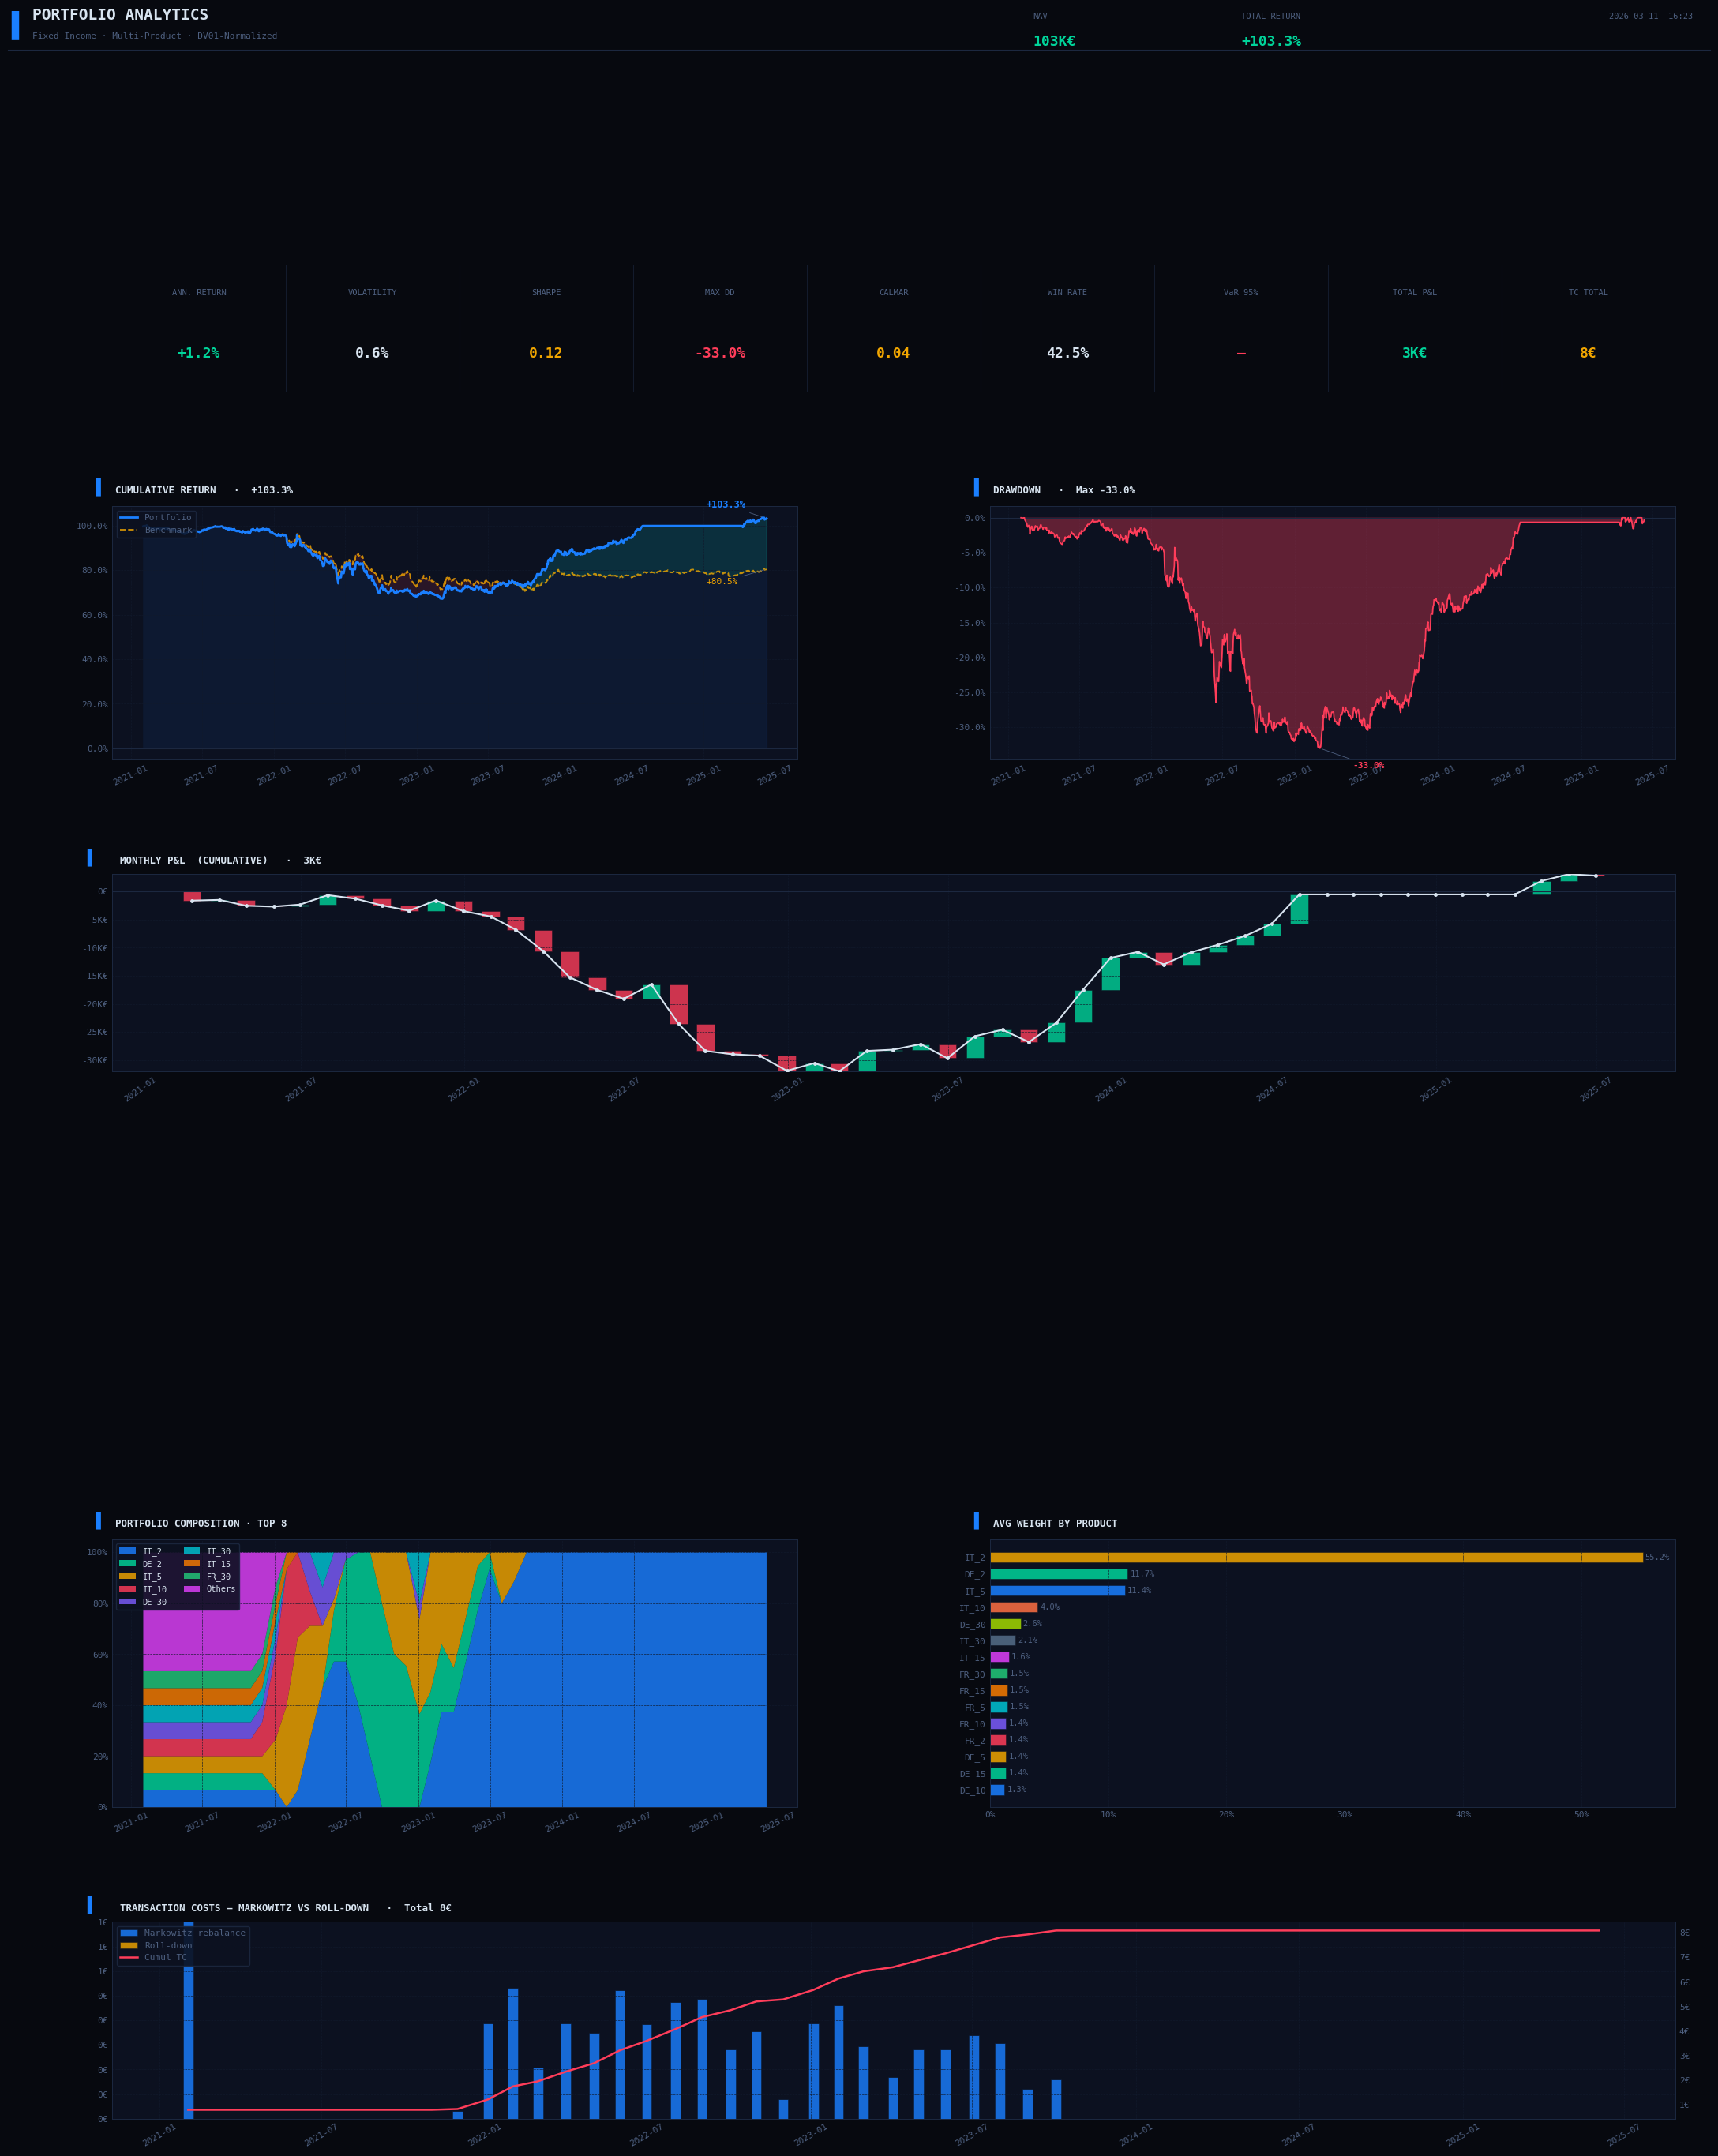

In [50]:
start_date = "2021-01-01"
end_date   = "2025-06-10"


tspf = TimeSeriesPortfolio(
    data=long_bond,
    start_date="2021-01-01",
    end_date="2025-06-10",
    rebalance_freq="ME",
    long_only=True,
    lamb=0.5,
    span=30,
    tc_gamma=0.075  # intensité des coûts dans l’optimisation
    #initial_weights= df_weights["weight"]
)
tspf.dv01_by_product = dv01_by_product


tspf.generate_portfolios()

viz = PortfolioDashboardVisualizer(ts_portfolio=tspf)
#viz.plot_dashboard(save_path="dashboard.png", dpi=200)

fig = viz.plot_dashboard()





In [33]:
tspf.metrics['portfolio_pnl'].cumsum()[-1]

-27605.42112486613

In [ ]:
import itertools
import warnings
warnings.filterwarnings("ignore")

# Grille d'hyperparamètres
lamb_values    = [0.005,0.2,0.5]
span_values    = [30]
tc_gamma_values = [0.007,0.0075, 0.008]

grid = list(itertools.product(lamb_values, span_values, tc_gamma_values))
print(f"Nombre de combinaisons : {len(grid)}")

results = []

for lamb, span, tc_gamma in grid:
    try:
        tspf = TimeSeriesPortfolio(
            data=long_bond,
            start_date="2021-01-01",
            end_date="2025-06-10",
            rebalance_freq="ME",
            long_only=False,
            lamb=lamb,
            span=span,
            tc_gamma=tc_gamma
        )
        tspf.generate_portfolios()

        results.append({
            "lamb":        lamb,
            "span":        span,
            "tc_gamma":    tc_gamma,
            "mean_return": tspf.metrics["mean_return"],
            "sharpe":      tspf.metrics["sharpe"],
            "volatility":  tspf.metrics["volatility"],
            "pf_pnl": tspf.metrics['portfolio_pnl'].cumsum()[-1],
            "tc_total":    tspf.metrics["transaction_costs"].sum(),
        })
        print(f"✓ lamb={lamb}, span={span}, tc_gamma={tc_gamma} → Sharpe={tspf.metrics['sharpe']:.3f}")

    except Exception as e:
        print(f"✗ lamb={lamb}, span={span}, tc_gamma={tc_gamma} → Erreur : {e}")
        results.append({
            "lamb": lamb, "span": span, "tc_gamma": tc_gamma,
            "mean_return": np.nan, "sharpe": np.nan,
            "volatility": np.nan, "max_drawdown": np.nan, "tc_total": np.nan,
        })

# DataFrame des résultats
df_grid = pd.DataFrame(results)

# Tri par Sharpe décroissant
df_grid = df_grid.sort_values("sharpe", ascending=False).reset_index(drop=True)

# Top 10
print("\n── Top 10 combinaisons (Sharpe net) ──")
print(df_grid.head(10).to_string(index=True))

Nombre de combinaisons : 9
Tout a marché !!
✓ lamb=0.005, span=30, tc_gamma=0.007 → Sharpe=-0.022
Tout a marché !!
✓ lamb=0.005, span=30, tc_gamma=0.0075 → Sharpe=-0.023


In [48]:
df_grid

,lamb,span,tc_gamma,mean_return,sharpe,volatility,pf_pnl,tc_total
0,0.5,30,0.0075,0.000042,0.105136,0.006408,2153.950259,9.048427
1,0.5,30,0.0010,0.000041,0.099543,0.006459,1907.163285,8.719248
2,0.5,30,0.0050,0.000040,0.097768,0.006439,1807.644090,9.055916
3,0.1,30,0.0075,0.000036,0.093099,0.006207,1531.145257,8.537217
4,0.1,30,0.0010,0.000036,0.090988,0.006264,1474.059275,7.941711
5,0.1,30,0.0050,0.000035,0.087909,0.006248,1309.117655,8.735653
6,0.1,60,0.0075,0.000030,0.067955,0.006936,350.448199,4.624920
7,0.5,60,0.0050,0.000027,0.067001,0.006500,186.975405,8.167633
8,0.5,60,0.0010,0.000026,0.062305,0.006540,-36.419042,7.597885
9,0.5,60,0.0075,0.000024,0.058844,0.006521,-203.791253,7.796152
